In [1]:
import numpy as np

# Input matrix
input_matrix = np.array([
    [1, 1, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 1, 1],
    [0, 0, 1, 1, 0],
    [0, 1, 1, 0, 0]
])

# 3 x 3 filter
kernel = np.array([
    [1, 0, 1],
    [0, 1, 0],
    [1, 0, 1]
])

# Stride and padding
stride = 1
padding = 0

# Calculate output dimensions
output_height = (
    input_matrix.shape[0] - kernel.shape[0] + 2 * padding
) // stride + 1

output_width = (
    input_matrix.shape[1] - kernel.shape[1] + 2 * padding
) // stride + 1

# Create empty output feature map
output = np.zeros((output_height, output_width))

# Slide the filter over the input
for i in range(0, input_matrix.shape[0] - kernel.shape[0] + 1, stride):

    for j in range(0, input_matrix.shape[1] - kernel.shape[1] + 1, stride):

        # Get the current 3 x 3 region
        region = input_matrix[
            i:i + kernel.shape[0],
            j:j + kernel.shape[1]
        ]

        # Element-wise multiplication and sum
        output[i // stride, j // stride] = np.sum(region * kernel)

# Print the result
print("Input Matrix:")
print(input_matrix)

print("\nFilter:")
print(kernel)

print("\nOutput Feature Map:")
print(output.astype(int))

print("\nOutput Shape:")
print(output.shape)

# Explanation:
# If the stride is changed from 1 to 2,
# the filter moves two positions at a time.
# Therefore, fewer positions are calculated
# and the output feature map becomes smaller.

Input Matrix:
[[1 1 1 0 0]
 [0 1 1 1 0]
 [0 0 1 1 1]
 [0 0 1 1 0]
 [0 1 1 0 0]]

Filter:
[[1 0 1]
 [0 1 0]
 [1 0 1]]

Output Feature Map:
[[4 3 4]
 [2 4 3]
 [2 3 4]]

Output Shape:
(3, 3)


In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: Colab is using CPU.")
    print("Go to Runtime -> Change runtime type -> T4 GPU")

PyTorch version: 2.11.0+cpu
CUDA available: False
Go to Runtime -> Change runtime type -> T4 GPU


DEVICE INFORMATION
Using device: cpu
This program will run on CPU and will be slower.

LOADING CIFAR-10 DATASET


100%|██████████| 170M/170M [34:24<00:00, 82.6kB/s]


CIFAR-10 loaded.

Training samples: 1000
Testing samples: 400

Data loaders created.

EXPERIMENT A: FROZEN FEATURE EXTRACTOR
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 246MB/s]


Trainable parameters: 1026

Epoch 1/2 | Loss: 0.6433 | Training Accuracy: 61.30%
Epoch 2/2 | Loss: 0.5333 | Training Accuracy: 73.70%

Experiment A training time: 178.98 seconds
Experiment A test accuracy: 76.75%

EXPERIMENT B: FINE-TUNING
Trainable parameters: 8394754

Epoch 1/2 | Loss: 0.5712 | Training Accuracy: 75.70%
Epoch 2/2 | Loss: 0.1316 | Training Accuracy: 94.40%

Experiment B training time: 243.93 seconds
Experiment B test accuracy: 85.75%



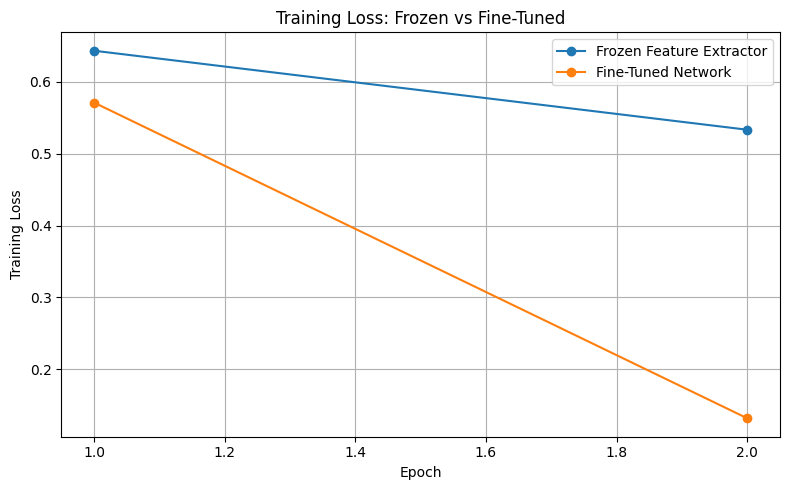

FINAL COMPARISON

Experiment A: Frozen Feature Extractor
Trainable Parameters: 1026
Training Time: 178.98 seconds
Test Accuracy: 76.75%

Experiment B: Fine-Tuning
Trainable Parameters: 8394754
Training Time: 243.93 seconds
Test Accuracy: 85.75%

ASSIGNMENT RESULTS
Method                           Parameters   Time (sec)     Accuracy
----------------------------------------------------------------------
Frozen Feature Extractor               1026       178.98       76.75%
Fine-Tuned Network                  8394754       243.93       85.75%

Loss plot saved as: transfer_learning_loss.png


In [2]:
# ============================================================
# CS5720 Neural Network and Deep Learning
# Home Assignment 3
#
# Part II - Q2
# Transfer Learning with a Pretrained ResNet18
#
# Experiment A: Frozen Feature Extractor
# Experiment B: Fine-Tuning
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import time
import copy

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torch.utils.data import Subset

from torchvision import datasets
from torchvision import transforms
from torchvision import models

import matplotlib.pyplot as plt


# ============================================================
# 2. CHECK DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 60)
print("DEVICE INFORMATION")
print("=" * 60)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not available.")
    print("This program will run on CPU and will be slower.")

print()


# ============================================================
# 3. SETTINGS
# ============================================================

# Number of images from each class.
# Smaller values make the assignment faster to run.
MAX_TRAIN_PER_CLASS = 500
MAX_TEST_PER_CLASS = 200

# Same number of epochs for both experiments.
EPOCHS = 2

# Batch size.
# 64 works well on a Colab GPU.
BATCH_SIZE = 64

# Learning rate.
LEARNING_RATE = 0.001

# Number of workers for loading images.
# Colab GPU usually works well with 2.
NUM_WORKERS = 2


# ============================================================
# 4. IMAGE TRANSFORMATION
# ============================================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# 5. DOWNLOAD CIFAR-10
# ============================================================

print("=" * 60)
print("LOADING CIFAR-10 DATASET")
print("=" * 60)

train_data = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("CIFAR-10 loaded.")
print()


# ============================================================
# 6. SELECT TWO CLASSES
#
# CIFAR-10 labels:
#
# 3 = cat
# 5 = dog
#
# We convert them to:
#
# cat = 0
# dog = 1
# ============================================================

def create_two_class_subset(dataset, max_per_class):

    selected_indices = []

    class_counts = {
        3: 0,
        5: 0
    }

    for index, label in enumerate(dataset.targets):

        if label in [3, 5]:

            if class_counts[label] < max_per_class:

                selected_indices.append(index)

                class_counts[label] += 1

        # Stop after collecting enough samples
        if (
            class_counts[3] >= max_per_class
            and class_counts[5] >= max_per_class
        ):
            break

    return Subset(dataset, selected_indices)


train_subset = create_two_class_subset(
    train_data,
    MAX_TRAIN_PER_CLASS
)

test_subset = create_two_class_subset(
    test_data,
    MAX_TEST_PER_CLASS
)

print("Training samples:", len(train_subset))
print("Testing samples:", len(test_subset))
print()


# ============================================================
# 7. CUSTOM DATASET WRAPPER
#
# This fixes the original error:
#
# CIFAR-10:
# cat = 3
# dog = 5
#
# ResNet classifier:
# class 0
# class 1
# ============================================================

class BinaryCIFAR10(torch.utils.data.Dataset):

    def __init__(self, subset):

        self.subset = subset

    def __len__(self):

        return len(self.subset)

    def __getitem__(self, index):

        image, label = self.subset[index]

        # Convert original CIFAR labels
        # 3 -> 0
        # 5 -> 1

        if label == 3:
            label = 0

        elif label == 5:
            label = 1

        else:
            raise ValueError(
                f"Unexpected CIFAR-10 label: {label}"
            )

        return image, label


train_dataset = BinaryCIFAR10(train_subset)

test_dataset = BinaryCIFAR10(test_subset)


# ============================================================
# 8. DATA LOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)


print("Data loaders created.")
print()


# ============================================================
# 9. CREATE PRETRAINED RESNET18
# ============================================================

def create_model():

    # Load pretrained ResNet18
    weights = models.ResNet18_Weights.DEFAULT

    model = models.resnet18(
        weights=weights
    )

    # Replace the original ImageNet classifier
    # with a binary classifier.
    model.fc = nn.Linear(
        model.fc.in_features,
        2
    )

    model = model.to(device)

    return model


# ============================================================
# 10. COUNT TRAINABLE PARAMETERS
# ============================================================

def count_trainable_parameters(model):

    total = 0

    for parameter in model.parameters():

        if parameter.requires_grad:

            total += parameter.numel()

    return total


# ============================================================
# 11. TRAINING FUNCTION
# ============================================================

def train_model(model, epochs):

    criterion = nn.CrossEntropyLoss()

    # Only parameters marked requires_grad=True
    # are passed to the optimizer.
    optimizer = optim.Adam(
        filter(
            lambda parameter: parameter.requires_grad,
            model.parameters()
        ),
        lr=LEARNING_RATE
    )

    training_losses = []

    start_time = time.time()


    # ========================================================
    # TRAINING LOOP
    # ========================================================

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0

        correct = 0
        total = 0


        for images, labels in train_loader:

            # Move data to GPU or CPU
            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )


            # Clear old gradients
            optimizer.zero_grad()


            # Forward propagation
            outputs = model(images)


            # Calculate loss
            loss = criterion(
                outputs,
                labels
            )


            # Backpropagation
            loss.backward()


            # Update trainable parameters
            optimizer.step()


            # Add loss
            running_loss += loss.item()


            # Calculate training accuracy
            predictions = outputs.argmax(
                dim=1
            )

            total += labels.size(0)

            correct += (
                predictions == labels
            ).sum().item()


        # Average loss
        epoch_loss = (
            running_loss /
            len(train_loader)
        )

        training_losses.append(
            epoch_loss
        )


        # Training accuracy
        epoch_accuracy = (
            100 * correct / total
        )


        print(
            f"Epoch {epoch + 1}/{epochs} "
            f"| Loss: {epoch_loss:.4f} "
            f"| Training Accuracy: "
            f"{epoch_accuracy:.2f}%"
        )


    # ========================================================
    # TRAINING TIME
    # ========================================================

    training_time = (
        time.time() - start_time
    )


    # ========================================================
    # TESTING
    # ========================================================

    model.eval()

    correct = 0
    total = 0


    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )


            outputs = model(images)


            predictions = outputs.argmax(
                dim=1
            )


            total += labels.size(0)

            correct += (
                predictions == labels
            ).sum().item()


    test_accuracy = (
        100 * correct / total
    )


    return (
        training_losses,
        training_time,
        test_accuracy
    )


# ============================================================
# 12. EXPERIMENT A
#
# FROZEN FEATURE EXTRACTOR
# ============================================================

print("=" * 60)
print("EXPERIMENT A: FROZEN FEATURE EXTRACTOR")
print("=" * 60)


model_a = create_model()


# Freeze all pretrained layers
for parameter in model_a.parameters():

    parameter.requires_grad = False


# Unfreeze only the new final classifier
for parameter in model_a.fc.parameters():

    parameter.requires_grad = True


# Count trainable parameters
trainable_a = count_trainable_parameters(
    model_a
)


print(
    "Trainable parameters:",
    trainable_a
)

print()


# Train Experiment A
loss_a, time_a, accuracy_a = train_model(
    model_a,
    EPOCHS
)


print()

print(
    f"Experiment A training time: "
    f"{time_a:.2f} seconds"
)

print(
    f"Experiment A test accuracy: "
    f"{accuracy_a:.2f}%"
)

print()


# ============================================================
# 13. EXPERIMENT B
#
# FINE-TUNING
# ============================================================

print("=" * 60)
print("EXPERIMENT B: FINE-TUNING")
print("=" * 60)


model_b = create_model()


# Freeze the entire pretrained network first
for parameter in model_b.parameters():

    parameter.requires_grad = False


# Unfreeze the final convolutional block
for parameter in model_b.layer4.parameters():

    parameter.requires_grad = True


# Unfreeze final classification layer
for parameter in model_b.fc.parameters():

    parameter.requires_grad = True


# Count trainable parameters
trainable_b = count_trainable_parameters(
    model_b
)


print(
    "Trainable parameters:",
    trainable_b
)

print()


# Train Experiment B
loss_b, time_b, accuracy_b = train_model(
    model_b,
    EPOCHS
)


print()

print(
    f"Experiment B training time: "
    f"{time_b:.2f} seconds"
)

print(
    f"Experiment B test accuracy: "
    f"{accuracy_b:.2f}%"
)

print()


# ============================================================
# 14. PLOT TRAINING LOSS
# ============================================================

epoch_numbers = range(
    1,
    EPOCHS + 1
)


plt.figure(figsize=(8, 5))


plt.plot(
    epoch_numbers,
    loss_a,
    marker="o",
    label="Frozen Feature Extractor"
)


plt.plot(
    epoch_numbers,
    loss_b,
    marker="o",
    label="Fine-Tuned Network"
)


plt.xlabel("Epoch")

plt.ylabel("Training Loss")

plt.title(
    "Training Loss: Frozen vs Fine-Tuned"
)

plt.legend()

plt.grid(True)

plt.tight_layout()


plt.savefig(
    "transfer_learning_loss.png"
)


plt.show()


# ============================================================
# 15. FINAL COMPARISON
# ============================================================

print("=" * 60)
print("FINAL COMPARISON")
print("=" * 60)


print()

print("Experiment A: Frozen Feature Extractor")

print(
    "Trainable Parameters:",
    trainable_a
)

print(
    f"Training Time: "
    f"{time_a:.2f} seconds"
)

print(
    f"Test Accuracy: "
    f"{accuracy_a:.2f}%"
)


print()

print("Experiment B: Fine-Tuning")

print(
    "Trainable Parameters:",
    trainable_b
)

print(
    f"Training Time: "
    f"{time_b:.2f} seconds"
)

print(
    f"Test Accuracy: "
    f"{accuracy_b:.2f}%"
)


print()

print("=" * 60)
print("ASSIGNMENT RESULTS")
print("=" * 60)

print(
    f"{'Method':30s} "
    f"{'Parameters':>12s} "
    f"{'Time (sec)':>12s} "
    f"{'Accuracy':>12s}"
)

print("-" * 70)

print(
    f"{'Frozen Feature Extractor':30s} "
    f"{trainable_a:>12d} "
    f"{time_a:>12.2f} "
    f"{accuracy_a:>11.2f}%"
)

print(
    f"{'Fine-Tuned Network':30s} "
    f"{trainable_b:>12d} "
    f"{time_b:>12.2f} "
    f"{accuracy_b:>11.2f}%"
)

print()

print(
    "Loss plot saved as: "
    "transfer_learning_loss.png"
)